In [296]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('Day2Data.csv')

# Replace column names with expected ones
df.rename(columns={"PCellRSRP": "RSRP", "PCellRSRQ": "RSRQ", "CINR": "SNR"}, inplace=True)

# Function to calculate composite scores with weights
def calculate_composite_score(w_rsrp, w_rsrq, w_snr):
    return (w_rsrp * df['RSRP']) + (w_rsrq * df['RSRQ']) + (w_snr * df['SNR'])

# Define initial weights
weights = {'RSRP': 0.5, 'RSRQ': 0.5, 'SNR': 0.5}
best_accuracy = 0
best_weights = weights

# Grid search for best weights
for w_rsrp in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    for w_rsrq in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        for w_snr in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
            if w_rsrp + w_rsrq + w_snr == 1:  # Ensure weights sum to 1
                df['Composite_Score'] = calculate_composite_score(w_rsrp, w_rsrq, w_snr)
                
                # Calculate thresholds
                excellent_threshold = df['Composite_Score'].quantile(0.9)
                good_threshold = df['Composite_Score'].quantile(0.5)
                moderate_threshold = df['Composite_Score'].quantile(0.15)
                
                # Label QSI categories
                def label_qsi(score):
                    if score >= excellent_threshold:
                        return "Excellent"
                    elif score >= good_threshold:
                        return "Good"
                    elif score >= moderate_threshold:
                        return "Moderate"
                    else:
                        return "Poor"
                
                df['QSI_Category'] = df['Composite_Score'].apply(label_qsi)
                
                # Prepare for logistic regression
                X = df[['RSRP', 'RSRQ', 'SNR']]
                y = df['QSI_Category']
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
                
                # Train model
                model = LogisticRegression()
                model.fit(X_train, y_train)
                
                # Evaluate accuracy
                y_pred = model.predict(X_test)
                accuracy = accuracy_score(y_test, y_pred)
                
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_weights = {'RSRP': w_rsrp, 'RSRQ': w_rsrq, 'SNR': w_snr}

# Calculate Composite Score with best weights
df['Composite_Score'] = calculate_composite_score(best_weights['RSRP'], best_weights['RSRQ'], best_weights['SNR'])


# Calculate thresholds
excellent_threshold = df['Composite_Score'].quantile(0.9)
good_threshold = df['Composite_Score'].quantile(0.5)
moderate_threshold = df['Composite_Score'].quantile(0.15)

# Label QSI categories again using best weights
def label_qsi(score):
    if score >= excellent_threshold:
        return "Excellent"
    elif score >= good_threshold:
        return "Good"
    elif score >= moderate_threshold:
        return "Moderate"
    else:
        return "Poor"

df['QSI_Category'] = df['Composite_Score'].apply(label_qsi)

# Output the results
print(f"Best Weights: {best_weights}")
print(f"Best Accuracy: {best_accuracy}")
# Save the dataset with QSI scores and categories
df.to_csv('Day2Data_with_QSI2.csv', index=False)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Best Weights: {'RSRP': 0.5, 'RSRQ': 0.2, 'SNR': 0.3}
Best Accuracy: 0.9923076923076923


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

In [297]:
df = pd.read_csv('Day2Data_with_QSI2.csv')
df.head(10)

,Timestamp,ServingCellID,RSRP,RSRQ,NeighCellId,NeighCellRSRP,NeighCellRSRQ,Handover,CINRvalue1,CINRvalue2,SNR,Composite_Score,QSI_Category
0,46:26.3,50,51,6.0,77,49.0,6.00,0,11,9,10.0,29.70,Good
1,46:26.3,50,51,6.0,162,47.0,4.00,0,11,9,10.0,29.70,Good
2,46:28.4,50,52,10.0,77,46.0,2.00,0,11,9,10.0,31.00,Good
3,46:38.9,50,48,4.0,77,47.0,7.00,0,1,-1,0.0,24.80,Moderate
4,46:39.3,50,51,6.0,77,49.0,6.00,0,2,-4,-1.0,26.40,Moderate
5,46:39.3,50,51,6.0,162,47.0,4.00,0,2,-4,-1.0,26.40,Moderate
6,46:40.2,50,48,5.0,77,50.0,10.25,0,-1,-4,-2.5,24.25,Moderate
7,46:40.4,50,49,3.0,77,55.0,14.50,1,-1,-4,-2.5,24.35,Moderate
8,46:42.0,50,60,14.0,77,52.0,18.75,1,-1,-4,-2.5,32.05,Good
9,46:43.2,77,50,23.0,50,52.0,25.00,0,7,9,8.0,32.00,Good


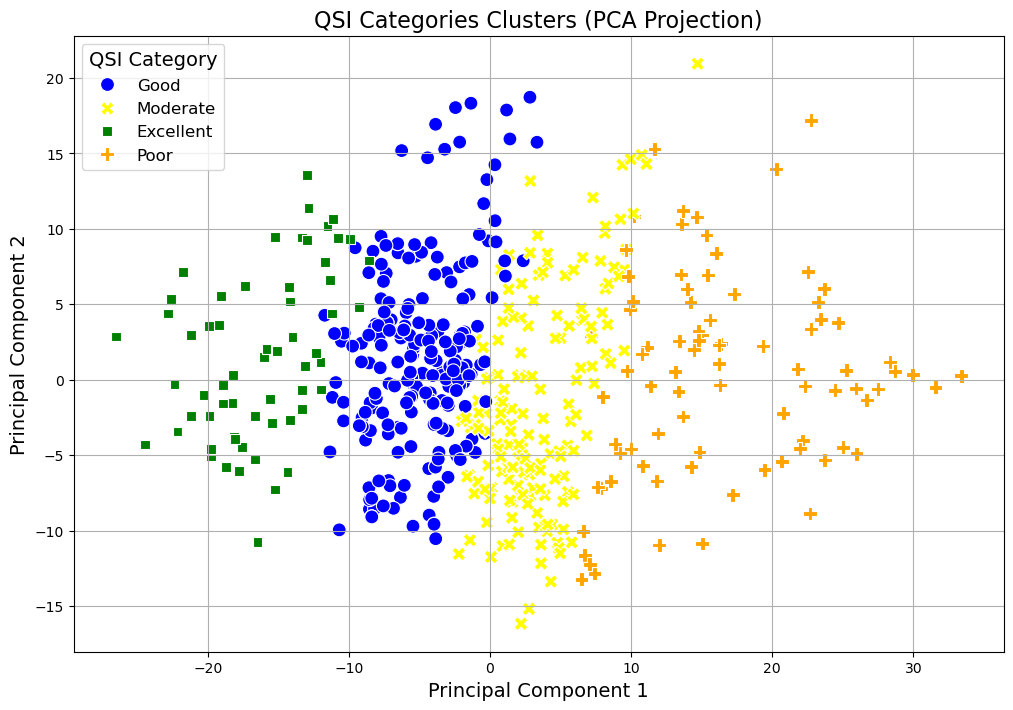

In [268]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Day2Data_with_QSI2.csv')

# Select the features for PCA
features = ['RSRP', 'RSRQ', 'SNR']

# Perform PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df[features])
df['PCA1'] = df_pca[:, 0]
df['PCA2'] = df_pca[:, 1]

# Define a color palette for the categories
palette = {
    'Excellent': 'green',
    'Good': 'blue',
    'Moderate': 'yellow',
    'Poor': 'orange',
}

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='QSI_Category',
    palette=palette,
    style='QSI_Category',
    s=100
)

# Add labels, title, and legend
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.title('QSI Categories Clusters (PCA Projection)', fontsize=16)
plt.legend(title='QSI Category', fontsize=12, title_fontsize=14, loc='upper left')
plt.grid(True)

# Save and display the plot

plt.show()


Centroids for each QSI_Category:
                   PCA1      PCA2
QSI_Category                     
Excellent    -16.042605  1.767194
Good          -4.831206  1.473416
Moderate       3.204059 -2.391944
Poor          16.350566  0.374912


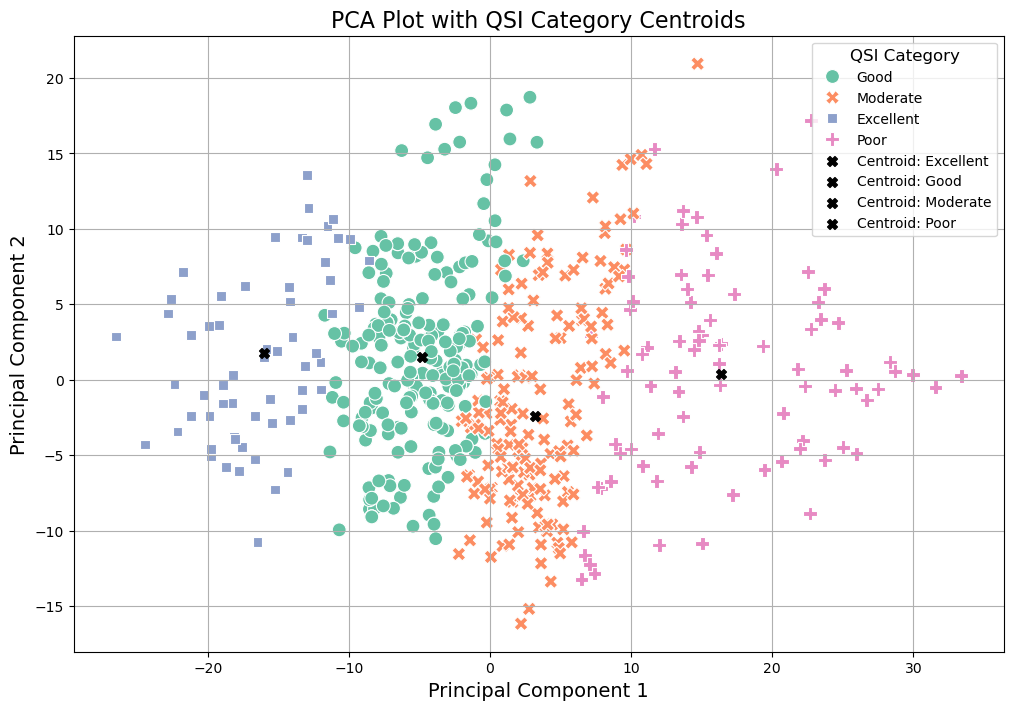

In [269]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Day2Data_with_QSI2.csv')

# Select the features for PCA
features = ['RSRP', 'RSRQ', 'SNR']

# Perform PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df[features])
df['PCA1'] = df_pca[:, 0]
df['PCA2'] = df_pca[:, 1]

# Calculate centroids for each QSI_Category
centroids = df.groupby('QSI_Category')[['PCA1', 'PCA2']].mean()

# Display the centroids
print("Centroids for each QSI_Category:")
print(centroids)

# Plot the PCA results with centroids
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='QSI_Category',
    palette='Set2',
    style='QSI_Category',
    s=100
)

# Plot centroids
for category, (x, y) in centroids.iterrows():
    plt.scatter(x, y, color='black', marker='X', s=50, label=f'Centroid: {category}')

# Add labels and title
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.title('PCA Plot with QSI Category Centroids', fontsize=16)
plt.legend(title='QSI Category', fontsize=10, title_fontsize=12, loc='best')
plt.grid(True)

# Show plot
plt.show()


Centroids for each QSI_Category:
                   PCA1      PCA2
QSI_Category                     
Excellent    -15.560957  1.506622
Good          -4.849614  1.032289
Moderate       2.746731 -3.427674
Poor          14.790149  0.557767


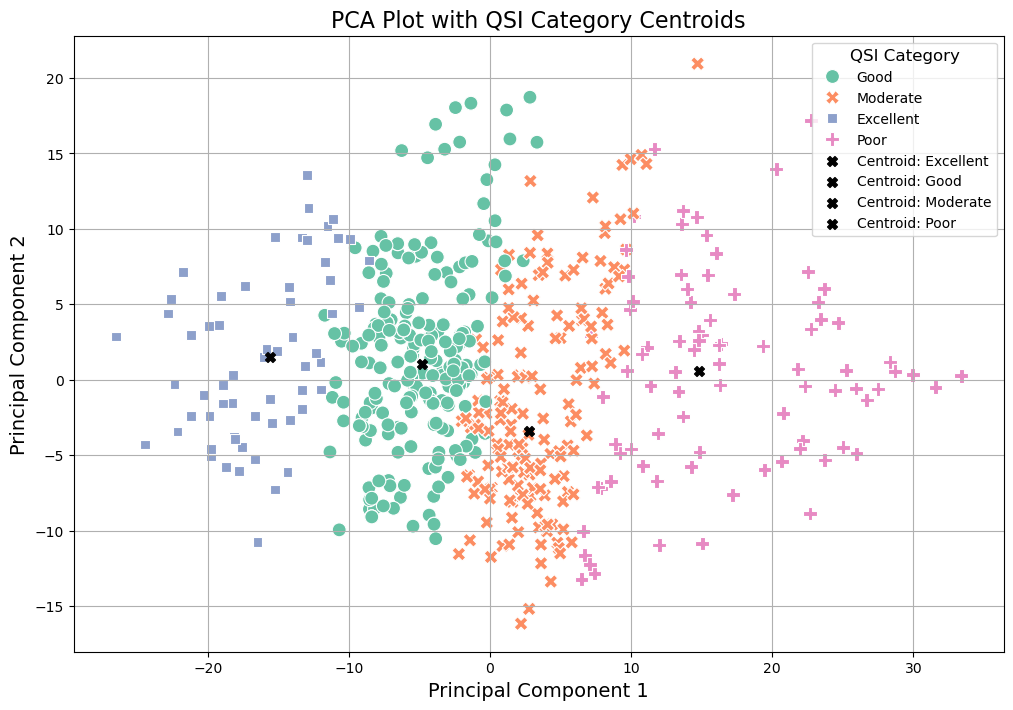

In [270]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Day2Data_with_QSI2.csv')

# Select the features for PCA
features = ['RSRP', 'RSRQ', 'SNR']

# Perform PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df[features])
df['PCA1'] = df_pca[:, 0]
df['PCA2'] = df_pca[:, 1]

# Calculate centroids for each QSI_Category
centroids = df.groupby('QSI_Category')[['PCA1', 'PCA2']].median()

# Display the centroids
print("Centroids for each QSI_Category:")
print(centroids)

# Plot the PCA results with centroids
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='QSI_Category',
    palette='Set2',
    style='QSI_Category',
    s=100
)

# Plot centroids
for category, (x, y) in centroids.iterrows():
    plt.scatter(x, y, color='black', marker='X', s=50, label=f'Centroid: {category}')

# Add labels and title
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.title('PCA Plot with QSI Category Centroids', fontsize=16)
plt.legend(title='QSI Category', fontsize=10, title_fontsize=12, loc='best')
plt.grid(True)

# Show plot
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


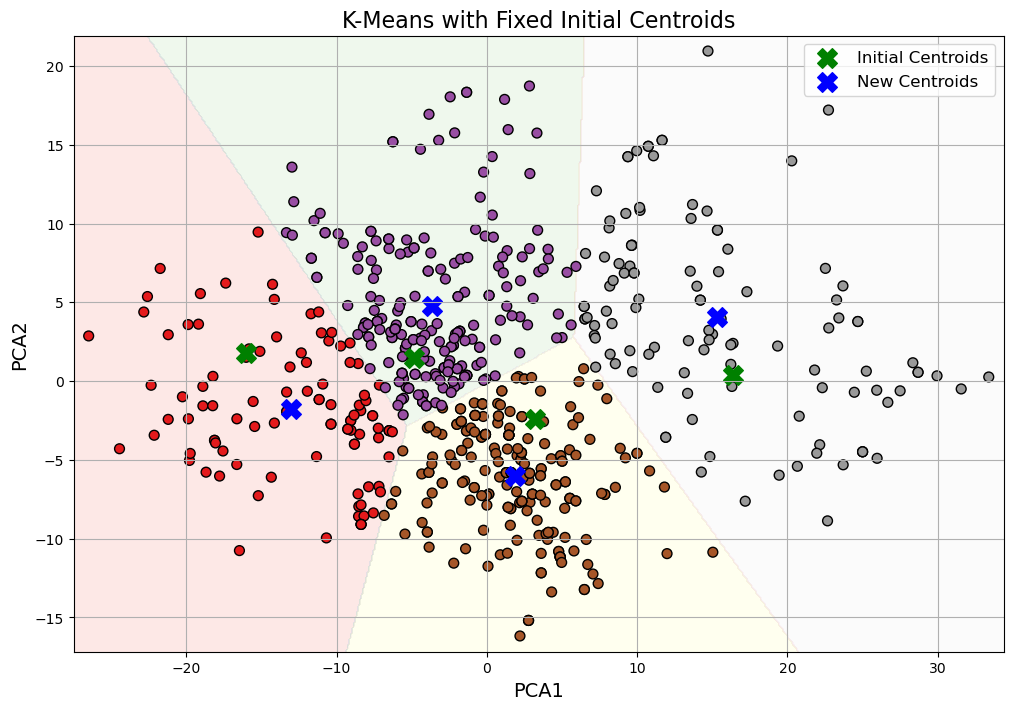

In [301]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('Day2Data_with_QSI2.csv')

# Select the features for PCA
features = ['RSRP', 'RSRQ', 'SNR']

# Perform PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df[features])
df['PCA1'] = df_pca[:, 0]
df['PCA2'] = df_pca[:, 1]

# Extract PCA data
data = df[['PCA1', 'PCA2']].values


# Manually specified initial centroids based on the given QSI categories
initial_centroids = np.array([
    [-16.042605,  1.767194],    # Excellent
    [-4.831206,  1.473416],     # Good
    [ 3.204059, -2.391944],     # Moderate
    [16.350566,  0.374912],     # Poor
])


# Perform KMeans with fixed centroids
kmeans = KMeans(
    n_clusters=4,
    init=initial_centroids,
    max_iter=200,
    random_state=42
)
kmeans.fit(data)

# Add cluster assignments to the dataset
df['Cluster'] = kmeans.labels_

# Map clusters to categories
cluster_to_category = {
    3: 'Poor',
    2: 'Moderate',
    1: 'Good',
    0: 'Excellent'
}
df['Category'] = df['Cluster'].map(cluster_to_category)

# Save the updated dataset
df.to_csv('Day2Data_with_ClustersPPP.csv', index=False)

# Plot decision boundaries
x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Pastel1')
plt.scatter(data[:, 0], data[:, 1], c=kmeans.labels_, cmap='Set1', edgecolor='k', s=50)
plt.scatter(initial_centroids[:, 0], initial_centroids[:, 1], c='green', marker='X', s=200, label='Initial Centroids')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='blue', marker='X', s=200, label='New Centroids')
plt.xlabel('PCA1', fontsize=14)
plt.ylabel('PCA2', fontsize=14)
plt.title('K-Means with Fixed Initial Centroids', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


In [302]:
import pandas as pd

# Load the dataset with clusters and QSI categories
df = pd.read_csv('Day2Data_with_ClustersPPP.csv')

# Ensure that both 'Category' and 'QSI_Category' columns are present
categories = ['Poor', 'Moderate', 'Good', 'Excellent']

# Initialize a dictionary to store the match counts for each category
match_counts = {category: {'correct': 0, 'total': 0} for category in categories}

# Compare the 'Category' and 'QSI_Category' columns
for category in categories:
    # Get the subset of data for the current category
    category_data = df[df['QSI_Category'] == category]
    
    # Count the number of times the predicted 'Category' matches the actual 'QSI_Category'
    correct_matches = (category_data['Category'] == category).sum()
    
    # Update match counts
    match_counts[category]['correct'] = correct_matches
    match_counts[category]['total'] = len(category_data)

# Calculate the accuracy for each category
accuracy_per_category = {category: match_counts[category]['correct'] / match_counts[category]['total'] 
                         for category in categories}

# Print the accuracy for each category
for category in categories:
    correct = match_counts[category]['correct']
    total = match_counts[category]['total']
    accuracy = accuracy_per_category[category]
    print(f"{category}: {correct}/{total} correct, Accuracy: {accuracy * 100:.2f}%")


Poor: 78/97 correct, Accuracy: 80.41%
Moderate: 160/224 correct, Accuracy: 71.43%
Good: 171/261 correct, Accuracy: 65.52%
Excellent: 50/65 correct, Accuracy: 76.92%


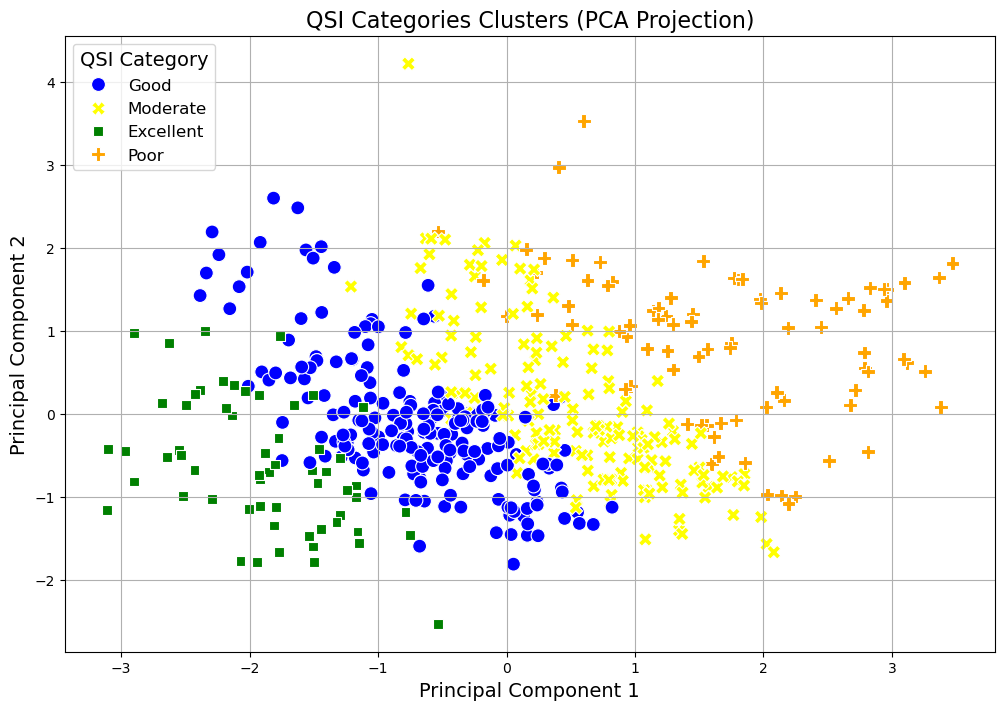

In [276]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Day2Data_with_QSI2.csv')

# Select the features for PCA
features = ['RSRP', 'RSRQ', 'SNR']

# Scale the features using StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])

# Perform PCA on the scaled data
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Add the PCA results to the dataframe
df['PCA1'] = df_pca[:, 0]
df['PCA2'] = df_pca[:, 1]

# Define a color palette for the categories
palette = {
    'Excellent': 'green',
    'Good': 'blue',
    'Moderate': 'yellow',
    'Poor': 'orange',
}

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='QSI_Category',
    palette=palette,
    style='QSI_Category',
    s=100
)

# Add labels, title, and legend
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.title('QSI Categories Clusters (PCA Projection)', fontsize=16)
plt.legend(title='QSI Category', fontsize=12, title_fontsize=14, loc='upper left')
plt.grid(True)

# Save and display the plot
plt.show()


Centroids for each QSI_Category:
                  PCA1      PCA2
QSI_Category                    
Excellent    -1.880470 -0.689649
Good         -0.638983 -0.178594
Moderate      0.650780 -0.263136
Poor          1.649552  1.070698


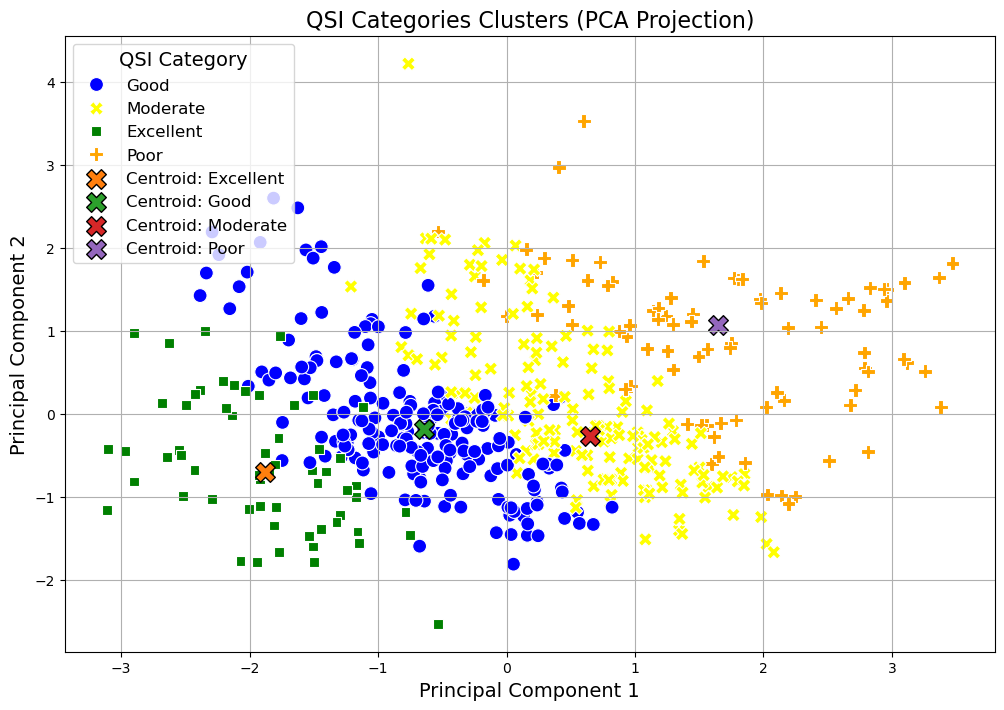

In [287]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Day2Data_with_QSI2.csv')

# Select the features for PCA
features = ['RSRP', 'RSRQ', 'SNR']

# Scale the features using StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])

# Perform PCA on the scaled data
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Add the PCA results to the dataframe
df['PCA1'] = df_pca[:, 0]
df['PCA2'] = df_pca[:, 1]

# Calculate the centroids for each QSI_Category by taking the mean of PCA1 and PCA2
centroids = df.groupby('QSI_Category')[['PCA1', 'PCA2']].median()

# Print the centroids
print("Centroids for each QSI_Category:")
print(centroids)

# Define a color palette for the categories
palette = {
    'Excellent': 'green',
    'Good': 'blue',
    'Moderate': 'yellow',
    'Poor': 'orange',
}

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='QSI_Category',
    palette=palette,
    style='QSI_Category',
    s=100
)

# Plot the centroids
for category, centroid in centroids.iterrows():
    plt.scatter(centroid['PCA1'], centroid['PCA2'], label=f'Centroid: {category}', s=200, marker='X', edgecolor='black')

# Add labels, title, and legend
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.title('QSI Categories Clusters (PCA Projection)', fontsize=16)
plt.legend(title='QSI Category', fontsize=12, title_fontsize=14, loc='upper left')
plt.grid(True)

# Save and display the plot
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


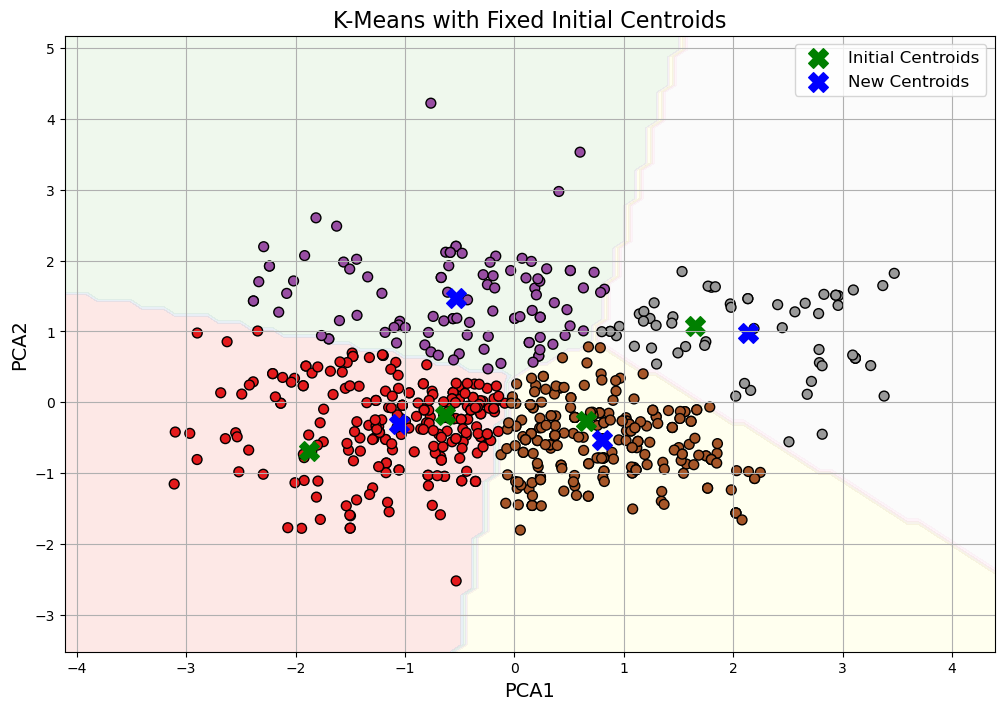

In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('Day2Data_with_QSI2.csv')

# Select the features for PCA
features = ['RSRP', 'RSRQ', 'SNR']

# Scale the features using StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])

# Perform PCA on the scaled data
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Add the PCA results to the dataframe
df['PCA1'] = df_pca[:, 0]
df['PCA2'] = df_pca[:, 1]

# Extract PCA data
data = df[['PCA1', 'PCA2']].values

initial_centroids = np.array([
    [-1.880470, -0.689649],   # Excellent
    [-0.638983, -0.178594],   # Good
    [ 0.650780, -0.263136],   # Moderate
    [ 1.649552,  1.070698],   # Poor
])

# Perform KMeans with fixed initial centroids
kmeans = KMeans(
    n_clusters=4,
    init=initial_centroids,
    max_iter=200,
    random_state=42
)
kmeans.fit(data)

# Add cluster assignments to the dataset
df['Cluster'] = kmeans.labels_

# Map clusters to categories
cluster_to_category = {
    3: 'Poor',
    2: 'Moderate',
    1: 'Good',
    0: 'Excellent'
}
df['Category'] = df['Cluster'].map(cluster_to_category)

# Save the updated dataset
df.to_csv('Day2Data_with_ClustersPPP.csv', index=False)

# Plot decision boundaries
x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Pastel1')
plt.scatter(data[:, 0], data[:, 1], c=kmeans.labels_, cmap='Set1', edgecolor='k', s=50)
plt.scatter(initial_centroids[:, 0], initial_centroids[:, 1], c='green', marker='X', s=200, label='Initial Centroids')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='blue', marker='X', s=200, label='New Centroids')
plt.xlabel('PCA1', fontsize=14)
plt.ylabel('PCA2', fontsize=14)
plt.title('K-Means with Fixed Initial Centroids', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


In [3]:
import pandas as pd

# Load the dataset with clusters and QSI categories
df = pd.read_csv('Day2Data_with_ClustersPPP.csv')

# Ensure that both 'Category' and 'QSI_Category' columns are present
categories = ['Poor', 'Moderate', 'Good', 'Excellent']

# Initialize a dictionary to store the match counts for each category
match_counts = {category: {'correct': 0, 'total': 0} for category in categories}

# Compare the 'Category' and 'QSI_Category' columns
for category in categories:
    # Get the subset of data for the current category
    category_data = df[df['QSI_Category'] == category]
    
    # Count the number of times the predicted 'Category' matches the actual 'QSI_Category'
    correct_matches = (category_data['Category'] == category).sum()
    
    # Update match counts
    match_counts[category]['correct'] = correct_matches
    match_counts[category]['total'] = len(category_data)

# Calculate the accuracy for each category
accuracy_per_category = {category: match_counts[category]['correct'] / match_counts[category]['total'] 
                         for category in categories}

# Print the accuracy for each category
for category in categories:
    correct = match_counts[category]['correct']
    total = match_counts[category]['total']
    accuracy = accuracy_per_category[category]
    print(f"{category}: {correct}/{total} correct, Accuracy: {accuracy * 100:.2f}%")


Poor: 57/97 correct, Accuracy: 58.76%
Moderate: 168/224 correct, Accuracy: 75.00%
Good: 31/261 correct, Accuracy: 11.88%
Excellent: 64/65 correct, Accuracy: 98.46%
